# Phase 4 — XGBoost Model V1
## Adaptive Real-Time Financial Transaction Fraud Detection System

**Notebook:** `notebooks/04_xgboost_model_v1.ipynb`  |  **Input:** `../data/processed/featured_transactions.parquet` (Phase 3 output)  |  **Target:** `isFraud`

> **What this notebook does:** trains, thresholds, evaluates, explains (via native feature importance only) and saves a reproducible baseline XGBoost model — **Model V1**.
> **What it does NOT do:** build Model V2, drift detection, retraining, Kafka/Spark, an API/dashboard, SHAP, or counterfactuals. Those are later phases.

## SECTION 1 — Phase 4 Introduction (viva-ready explanations)

**Why XGBoost?** Gradient-boosted trees handle tabular data with mixed scales and skewed distributions (Phase 2/3 showed `amount` is heavily skewed) without feature scaling, natively support missing values (Phase 3 leaves ratios as `NaN` by design), and are the standard strong baseline for structured fraud-detection problems.

**Why a temporal split, not a random split?** Transactions are ordered in time. A random split would let the model train on transactions that happen *after* some of its test transactions — information a real deployed model could never have. A chronological split (earlier → train, later → validation, latest → test) is the only split that honestly simulates production.

**Why does class imbalance matter?** Fraud is a small minority of transactions (Phase 2/3 measured the exact rate below). A model that always predicts "legitimate" would already score very high on accuracy while catching zero fraud.

**Why is accuracy insufficient?** Because of the imbalance above, accuracy is dominated by the majority class and barely moves even if the model misses most fraud. It is reported here only as a secondary, contextual number.

**Why PR-AUC (Average Precision)?** ROC-AUC can look deceptively good under heavy imbalance because it rewards correctly ranking the (huge) majority of true negatives. PR-AUC focuses on precision and recall of the **positive (fraud)** class as the threshold varies, so it better reflects how usable the model is for actually catching fraud without drowning analysts in false alarms.

**Why threshold tuning?** `predict_proba` gives a continuous fraud probability; turning it into a yes/no decision needs a cut-off. 0.50 is arbitrary and, under heavy imbalance, is usually far from the best operating point. The threshold is chosen on **validation** data using a documented objective (Section 10) and never touched again on the test set.

**Precision, recall, F1 in plain terms**
* **Precision** = of the transactions the model calls fraud, how many really are fraud. Low precision → many false alarms → wasted analyst time / annoyed customers.
* **Recall** = of the real frauds, how many the model catches. Low recall → fraud slips through.
* **F1** = harmonic mean of precision and recall — a single number that penalises a bad score on either.

**False positives vs. false negatives in fraud detection.** A false positive blocks or flags a legitimate customer transaction (friction, complaints, lost trust). A false negative lets a fraudulent transaction through (financial loss). The two costs are different in kind, which is exactly why a single accuracy number is not enough and why the threshold section documents the trade-off explicitly instead of picking 0.50 by default.

**What the risk score means.** It is `fraud_probability × 100`, i.e. a 0–100 rescaling of the model's own output — **not** a professionally calibrated financial risk figure. Section 21 checks how well-calibrated the raw probability actually is.

**Why save Model V1?** So Phase 5+ (deployment, streaming, drift monitoring, retraining) can load a fixed, versioned artifact and compare future models (V2, V3, …) against it fairly.

**Why no SHAP yet?** SHAP explanations are meaningful only once there is a trained, saved model to explain — that is Phase 8. Native XGBoost feature importance is provided here to give qualitative insight without pre-empting the dedicated explainability phase.

## SECTION 2 — Import Libraries

In [6]:
%pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import sys
!{sys.executable} -m pip install xgboost

'c:\Users\MYSHA' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
import os
import json
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, f1_score, precision_recall_curve, roc_curve,
                             average_precision_score, roc_auc_score, confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
import xgboost as xgb
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "axes.titlesize": 12})
pd.options.display.float_format = "{:,.4f}".format
pd.options.display.max_columns = 60

SEED = 42
np.random.seed(SEED)
print("pandas", pd.__version__, "| numpy", np.__version__, "| xgboost", xgb.__version__)
CHECK = {}
PHASE4_START = time.time()

pandas 2.2.2 | numpy 1.26.4 | xgboost 3.4.1


## SECTION 3 — Configuration

All paths are **relative**, assuming execution from inside `notebooks/`. Only the existing `models/` and `reports/` folders are used; nothing outside Phase 4's own files is created or overwritten.

In [9]:
DATA_PATH = Path("../data/processed/featured_transactions.parquet")
SELECTED_FEATURES_PATH = Path("../reports/selected_features.csv")     # optional (Phase 3); used only as a cross-check

MODELS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"
MODEL_PATH = MODELS_DIR / "xgboost_model_v1.json"
THRESHOLD_PATH = MODELS_DIR / "model_v1_threshold.json"
METADATA_PATH = MODELS_DIR / "model_v1_metadata.json"
METRICS_PATH = REPORTS_DIR / "model_v1_metrics.csv"
FEATURE_IMPORTANCE_CSV = REPORTS_DIR / "model_v1_feature_importance.csv"
TEST_PREDICTIONS_PATH = REPORTS_DIR / "model_v1_test_predictions.csv"

TARGET = "isFraud"
META_COLS = ["event_id", "step"]                 # present in the Phase 3 output; NOT model features

TRAIN_FRACTION, VAL_FRACTION, TEST_FRACTION = 0.70, 0.15, 0.15
THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.05), 2)
RISK_LEVELS = {"LOW": (0, 30), "MEDIUM": (30, 70), "HIGH": (70, 100)}   # risk-SCORE display bands (0-100); independent of the classification threshold
SAMPLE_TABLE_SIZE = 20

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {0: "#4C72B0", 1: "#C44E52"}
CLASS_NAMES = {0: "Legitimate", 1: "Fraud"}


def save_fig(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print("Figure saved ->", path)


def pct(part, whole):
    return 100.0 * part / whole if whole else 0.0


print("Data path      :", DATA_PATH)
print("Models dir     :", MODELS_DIR)
print("Reports dir    :", REPORTS_DIR)

Data path      : ..\data\processed\featured_transactions.parquet
Models dir     : ..\models
Reports dir    : ..\reports


## SECTION 4 — Load the Phase 3 Data

**Purpose:** load the featured dataset produced by Phase 3, and fail with a clear, specific message if Phase 3 has not been run.

In [10]:
def load_featured_dataset(path):
    """Load the Phase 3 output. Raises a clear, specific error if it is missing or malformed."""
    if not path.is_file():
        raise FileNotFoundError(
            f"\n\nExpected Phase 3 output not found at: {path.resolve()}\n"
            "Phase 3 (03_feature_engineering.ipynb) must be run successfully first; it produces this file.\n"
            "No fake data will be created in its place.\n")
    try:
        frame = pd.read_parquet(path)
    except Exception as exc:                                    # noqa: BLE001 - report clearly, then re-raise
        raise ValueError(f"Failed to read '{path}' as Parquet ({exc}). "
                         "If Phase 3 fell back to CSV, load '../data/processed/featured_transactions.csv.gz' instead.") from exc
    if TARGET not in frame.columns:
        raise ValueError(f"Target column '{TARGET}' not found in the Phase 3 output. Re-run Phase 3.")
    if frame.empty:
        raise ValueError("The Phase 3 output is empty. Re-run Phase 3.")
    return frame


raw = load_featured_dataset(DATA_PATH)
CHECK["Phase 3 processed dataset loaded"] = True

print("Shape             :", raw.shape)
print("Columns           :", raw.columns.tolist())
print("\nData types:")
print(raw.dtypes.to_string())
print(f"\nMemory usage      : {raw.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB")
print("\nTarget column     :", TARGET)
print("Target distribution:")
print(raw[TARGET].value_counts().to_string())
print(f"\nMissing cells     : {int(raw.isna().sum().sum()):,}")
float_cols_all = raw.select_dtypes(include=["float32", "float64"]).columns.tolist()
inf_total = int(sum(np.isinf(raw[c].to_numpy()).sum() for c in float_cols_all))
print(f"Infinite values   : {inf_total:,}")
display(raw.head())

Shape             : (6362620, 37)
Columns           : ['event_id', 'step', 'hour_of_day', 'amount', 'log_amount', 'is_large_amount', 'amount_to_sender_balance_ratio', 'amount_ge_sender_balance', 'sender_remaining_if_debited', 'amount_to_dest_balance_ratio', 'sender_balance_before', 'sender_balance_zero_before', 'dest_balance_before', 'dest_balance_zero_before', 'sender_prev_txn_count', 'sender_prev_total_amount', 'sender_prev_mean_amount', 'sender_prev_max_amount', 'dest_prev_txn_count', 'dest_prev_total_amount', 'dest_prev_mean_amount', 'dest_prev_max_amount', 'amount_vs_sender_hist_mean', 'amount_vs_dest_hist_mean', 'sender_hours_since_prev_txn', 'dest_hours_since_prev_txn', 'dest_txn_count_last_1h', 'dest_txn_count_last_24h', 'dest_txn_count_last_168h', 'dest_amount_sum_last_24h', 'dest_amount_sum_last_168h', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'isFraud']

Data types:
event_id                            int32
step                          

,event_id,step,hour_of_day,amount,log_amount,is_large_amount,amount_to_sender_balance_ratio,amount_ge_sender_balance,sender_remaining_if_debited,amount_to_dest_balance_ratio,sender_balance_before,sender_balance_zero_before,dest_balance_before,dest_balance_zero_before,sender_prev_txn_count,sender_prev_total_amount,sender_prev_mean_amount,sender_prev_max_amount,dest_prev_txn_count,dest_prev_total_amount,dest_prev_mean_amount,dest_prev_max_amount,amount_vs_sender_hist_mean,amount_vs_dest_hist_mean,sender_hours_since_prev_txn,dest_hours_since_prev_txn,dest_txn_count_last_1h,dest_txn_count_last_24h,dest_txn_count_last_168h,dest_amount_sum_last_24h,dest_amount_sum_last_168h,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,0,1,0,"9,839.6400",9.1943,0,0.0578,0,"160,296.3594",NaN,"170,136.0000",0,0.0000,1,0,0.0000,NaN,NaN,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0.0000,0.0000,0,0,0,1,0,0
1,1,1,0,"1,864.2800",7.5312,0,0.0877,0,"19,384.7207",NaN,"21,249.0000",0,0.0000,1,0,0.0000,NaN,NaN,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0.0000,0.0000,0,0,0,1,0,0
2,2,1,0,181.0000,5.2040,0,1.0000,1,0.0000,NaN,181.0000,0,0.0000,1,0,0.0000,NaN,NaN,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0.0000,0.0000,0,0,0,0,1,1
3,3,1,0,181.0000,5.2040,0,1.0000,1,0.0000,0.0085,181.0000,0,"21,182.0000",0,0,0.0000,NaN,NaN,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0.0000,0.0000,0,1,0,0,0,1
4,4,1,0,"11,668.1400",9.3647,0,0.2808,0,"29,885.8594",NaN,"41,554.0000",0,0.0000,1,0,0.0000,NaN,NaN,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0.0000,0.0000,0,0,0,1,0,0


## SECTION 5 — Identify Target

The label is popped out **before** any feature list is built, so it is structurally impossible for it to end up inside `X`.

In [11]:
assert raw["step"].is_monotonic_increasing, "Phase 3 output must already be in chronological order."

y_all = raw.pop(TARGET).astype("int8")
meta_all = raw[[c for c in META_COLS if c in raw.columns]].copy()
X_all_raw = raw.drop(columns=[c for c in META_COLS if c in raw.columns])
del raw

assert TARGET not in X_all_raw.columns, "CRITICAL: target leaked into the feature frame."
print("Target column       :", TARGET)
print("Number of features   :", X_all_raw.shape[1])
print("Number of samples    :", len(X_all_raw))
print(f"isFraud present in X : {TARGET in X_all_raw.columns}  (must be False)")

Target column       : isFraud
Number of features   : 34
Number of samples    : 6362620
isFraud present in X : False  (must be False)


## SECTION 6 — Identify Final Features

Phase 3 already performed feature engineering and leakage screening; this notebook does **not** re-engineer anything. It only decides which columns of the Phase 3 output become model inputs, using two guards:

1. **Metadata columns** (`event_id`, `step`) are excluded — they are identifiers/ordering keys, not features.
2. If `../reports/selected_features.csv` (from Phase 3) is available, it is used as a **cross-check**: any Phase-3-approved feature missing from the parquet file is reported, and any parquet column *not* on the Phase 3 list is flagged and excluded rather than silently trusted.

If the Phase 3 report is not available, every non-metadata, non-target column of the parquet file is used (Phase 3 is documented to already save only its selected, leakage-screened features into this file).

In [12]:
def resolve_final_features(x_columns, selected_features_path):
    """Cross-check the parquet columns against Phase 3's approved feature list, if present."""
    candidate = list(x_columns)
    if selected_features_path.is_file():
        approved = pd.read_csv(selected_features_path)["Feature"].tolist()
        missing_from_data = [f for f in approved if f not in candidate]
        extra_in_data = [f for f in candidate if f not in approved]
        if missing_from_data:
            print("WARNING - Phase 3 approved features missing from the parquet file (skipped):", missing_from_data)
        if extra_in_data:
            print("WARNING - columns present in the data but NOT on Phase 3's approved list (excluded here):", extra_in_data)
        final = [f for f in approved if f in candidate]
        source = f"cross-checked against {selected_features_path}"
    else:
        final = candidate
        source = "no Phase 3 feature report found; using all non-metadata columns of the parquet file"
    return final, source


FINAL_FEATURES, FEATURE_SOURCE = resolve_final_features(X_all_raw.columns, SELECTED_FEATURES_PATH)
print("Feature source:", FEATURE_SOURCE)
print(f"Final feature count: {len(FINAL_FEATURES)}")
print(FINAL_FEATURES)

X_all = X_all_raw[FINAL_FEATURES].copy()
del X_all_raw
assert TARGET not in X_all.columns
CHECK["Target identified correctly"] = True
CHECK["Leakage-prone features excluded"] = True
CHECK["Final safe features selected"] = True

Feature source: cross-checked against ..\reports\selected_features.csv
Final feature count: 34
['hour_of_day', 'amount', 'log_amount', 'is_large_amount', 'amount_to_sender_balance_ratio', 'amount_ge_sender_balance', 'sender_remaining_if_debited', 'amount_to_dest_balance_ratio', 'sender_balance_before', 'sender_balance_zero_before', 'dest_balance_before', 'dest_balance_zero_before', 'sender_prev_txn_count', 'sender_prev_total_amount', 'sender_prev_mean_amount', 'sender_prev_max_amount', 'dest_prev_txn_count', 'dest_prev_total_amount', 'dest_prev_mean_amount', 'dest_prev_max_amount', 'amount_vs_sender_hist_mean', 'amount_vs_dest_hist_mean', 'sender_hours_since_prev_txn', 'dest_hours_since_prev_txn', 'dest_txn_count_last_1h', 'dest_txn_count_last_24h', 'dest_txn_count_last_168h', 'dest_amount_sum_last_24h', 'dest_amount_sum_last_168h', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## SECTION 7 — Data Quality Check

**Purpose:** confirm the Phase 3 output is trustworthy before any model sees it. Nothing is silently patched — every decision below is printed.

In [13]:
def data_quality_check(X, y_values, meta):
    report = {}
    report["missing_values_total"] = int(X.isna().sum().sum())
    report["missing_by_feature"] = {c: int(n) for c, n in X.isna().sum().items() if n > 0}
    float_cols = X.select_dtypes(include=["float32", "float64"]).columns.tolist()
    report["infinite_values_total"] = int(sum(np.isinf(X[c].to_numpy()).sum() for c in float_cols))
    report["duplicate_rows"] = int(X.duplicated().sum())
    report["invalid_target_values"] = int((~y_values.isin([0, 1])).sum())
    nunique = X.nunique(dropna=False)
    report["constant_columns"] = nunique.index[nunique <= 1].tolist()
    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    report["non_numeric_columns"] = non_numeric
    ranges = X.describe().T[["min", "max"]]
    report["extreme_ranges"] = ranges[(ranges["max"].abs() > 1e12) | (ranges["min"].abs() > 1e12)].to_dict(orient="index")
    report["chronological_order_ok"] = bool(meta["step"].is_monotonic_increasing) if "step" in meta.columns else None
    return report


DQ_REPORT = data_quality_check(X_all, y_all, meta_all)
print("DATA QUALITY REPORT")
for k, v in DQ_REPORT.items():
    print(f"  {k:<24}: {v}")

assert DQ_REPORT["invalid_target_values"] == 0, "Target contains values outside {0,1}"
assert not DQ_REPORT["non_numeric_columns"], f"Non-numeric feature columns found: {DQ_REPORT['non_numeric_columns']}"
if DQ_REPORT["constant_columns"]:
    print(f"\nDropping constant columns (no information for the model): {DQ_REPORT['constant_columns']}")
    FINAL_FEATURES = [f for f in FINAL_FEATURES if f not in DQ_REPORT["constant_columns"]]
    X_all = X_all[FINAL_FEATURES]
if DQ_REPORT["missing_values_total"]:
    print(f"\n{DQ_REPORT['missing_values_total']:,} missing values present (NaN, by design from Phase 3 — e.g. undefined ratios). "
          "XGBoost handles NaN natively via its default-direction split; no imputation is applied.")
if DQ_REPORT["infinite_values_total"]:
    raise ValueError("Infinite values found in the Phase 3 output - this should not happen; re-run Phase 3.")
if DQ_REPORT["duplicate_rows"]:
    print(f"\n{DQ_REPORT['duplicate_rows']:,} rows have identical feature values. Not removed: different transactions can "
          "legitimately share feature values, and rows are still distinct events (different event_id/step).")
print("\nData quality check complete. Proceeding with", X_all.shape[1], "features.")

DATA QUALITY REPORT
  missing_values_total    : 41109515
  missing_by_feature      : {'amount_to_sender_balance_ratio': 2102449, 'amount_to_dest_balance_ratio': 2704388, 'sender_prev_mean_amount': 6353307, 'sender_prev_max_amount': 6353307, 'dest_prev_mean_amount': 2722362, 'dest_prev_max_amount': 2722362, 'amount_vs_sender_hist_mean': 6353307, 'amount_vs_dest_hist_mean': 2722364, 'sender_hours_since_prev_txn': 6353307, 'dest_hours_since_prev_txn': 2722362}
  infinite_values_total   : 0
  duplicate_rows          : 8182
  invalid_target_values   : 0
  constant_columns        : []
  non_numeric_columns     : []
  extreme_ranges          : {}
  chronological_order_ok  : True

41,109,515 missing values present (NaN, by design from Phase 3 — e.g. undefined ratios). XGBoost handles NaN natively via its default-direction split; no imputation is applied.

8,182 rows have identical feature values. Not removed: different transactions can legitimately share feature values, and rows are still dist

## SECTION 8 — Chronological Train / Validation / Test Split

**This is critical.** Transactions are ordered by `step` (Phase 2/3). Shuffling randomly before splitting would let the model see transactions from *after* its own test period during training — an unrealistic and misleading evaluation.

Split (chosen from the Phase 2 temporal structure): the **earliest 70%** of transactions → training, the **next 15%** → validation, the **latest 15%** → test. Boundaries are chosen on the transaction **count** (cumulative share of rows by `step`), which is the same approach Phase 2's temporal-split plan used, so every split still contains fraud examples.

,Split,Step range,Rows,Fraud count,Fraud %,% of all rows
0,Train,<= 323,4463587,3643,0.0816,70.1533
1,Validation,324 .. 378,980416,564,0.0575,15.4090
2,Test,> 378,918617,4006,0.4361,14.4377


Train        period <= 323           rows=4,463,587  fraud=3,643 (0.0816%)
Validation   period 324 .. 378       rows=980,416  fraud=564 (0.0575%)
Test         period > 378            rows=918,617  fraud=4,006 (0.4361%)

Every split contains fraud examples, so precision/recall/PR-AUC can be computed on each.
Figure saved -> ..\reports\figures\model_v1_temporal_split.png


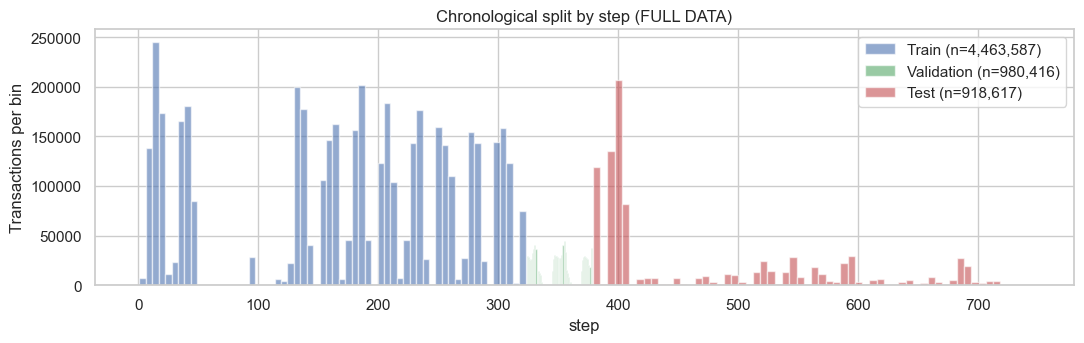

In [14]:
def chronological_split(meta, train_frac, val_frac):
    """Return boolean masks (train, val, test) using cumulative transaction share by step."""
    steps = meta["step"].to_numpy()
    step_counts = pd.Series(steps).value_counts().sort_index()
    cum_share = step_counts.cumsum() / step_counts.sum()
    train_end_step = int(cum_share[cum_share >= train_frac].index[0])
    val_end_step = int(cum_share[cum_share >= train_frac + val_frac].index[0])
    return (steps <= train_end_step), (steps > train_end_step) & (steps <= val_end_step), (steps > val_end_step), train_end_step, val_end_step


train_mask, val_mask, test_mask, TRAIN_END_STEP, VAL_END_STEP = chronological_split(meta_all, TRAIN_FRACTION, VAL_FRACTION)
assert train_mask.sum() + val_mask.sum() + test_mask.sum() == len(X_all)
assert not (train_mask & val_mask).any() and not (val_mask & test_mask).any()
# ordering guarantee: every training step precedes every validation step precedes every test step
assert meta_all.loc[train_mask, "step"].max() <= meta_all.loc[val_mask, "step"].min()
assert meta_all.loc[val_mask, "step"].max() <= meta_all.loc[test_mask, "step"].min()

X_train, y_train = X_all.loc[train_mask], y_all.loc[train_mask]
X_val, y_val = X_all.loc[val_mask], y_all.loc[val_mask]
X_test, y_test = X_all.loc[test_mask], y_all.loc[test_mask]
meta_test = meta_all.loc[test_mask].reset_index(drop=True)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Step range": [f"<= {TRAIN_END_STEP}", f"{TRAIN_END_STEP + 1} .. {VAL_END_STEP}", f"> {VAL_END_STEP}"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "Fraud count": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
})
split_summary["Fraud %"] = 100 * split_summary["Fraud count"] / split_summary["Rows"]
split_summary["% of all rows"] = 100 * split_summary["Rows"] / len(X_all)
display(split_summary)
for _, r in split_summary.iterrows():
    print(f"{r['Split']:<12} period {r['Step range']:<16} rows={int(r['Rows']):,}  fraud={int(r['Fraud count']):,} ({r['Fraud %']:.4f}%)")
assert (split_summary["Fraud count"] > 0).all(), "A split with zero fraud rows would make evaluation impossible - inspect the temporal split."
print("\nEvery split contains fraud examples, so precision/recall/PR-AUC can be computed on each.")
CHECK["Temporal ordering preserved"] = True
CHECK["Chronological train/validation/test split created"] = True

fig, ax = plt.subplots(figsize=(11, 3.6))
for name, m, color in (("Train", train_mask, "#4C72B0"), ("Validation", val_mask, "#55A868"), ("Test", test_mask, "#C44E52")):
    s = meta_all.loc[m, "step"]
    ax.hist(s, bins=60, alpha=0.6, label=f"{name} (n={m.sum():,})", color=color)
ax.set(title="Chronological split by step (FULL DATA)", xlabel="step", ylabel="Transactions per bin")
ax.legend()
plt.tight_layout()
save_fig(fig, "model_v1_temporal_split.png")
plt.show()

## SECTION 9 — Class Imbalance

**Reported and compensated for, never fixed by resampling.** Class imbalance is a property of the (training) data; Model V1 handles it through XGBoost's `scale_pos_weight`, not by deleting legitimate transactions or synthesising fraud rows.

`scale_pos_weight = (negative count) / (positive count)`, computed **only from the training split**. Using validation or test data to compute it would leak information about those sets into training.

In [15]:
def class_imbalance_report(y_values, name):
    n = len(y_values)
    fraud = int(y_values.sum())
    legit = n - fraud
    return {"split": name, "rows": n, "legitimate": legit, "fraud": fraud, "fraud_pct": pct(fraud, n),
            "imbalance_ratio": (legit / fraud) if fraud else float("inf")}


imbalance_tbl = pd.DataFrame([class_imbalance_report(y_train, "Train"), class_imbalance_report(y_val, "Validation"),
                              class_imbalance_report(y_test, "Test")]).set_index("split")
display(imbalance_tbl)

neg_train, pos_train = int((y_train == 0).sum()), int((y_train == 1).sum())
SCALE_POS_WEIGHT = neg_train / pos_train
print(f"\nTraining negatives (legitimate): {neg_train:,}")
print(f"Training positives (fraud)      : {pos_train:,}")
print(f"scale_pos_weight = {neg_train:,} / {pos_train:,} = {SCALE_POS_WEIGHT:.4f}")
print("\nThis constant is computed ONLY from the training split, so it carries no information from validation/test.")
print("No SMOTE, oversampling, or undersampling is applied anywhere in this notebook.")
CHECK["Class imbalance analyzed"] = True
CHECK["scale_pos_weight calculated from training data"] = True

,rows,legitimate,fraud,fraud_pct,imbalance_ratio
split,,,,,
Train,4463587,4459944,3643,0.0816,"1,224.2503"
Validation,980416,979852,564,0.0575,"1,737.3262"
Test,918617,914611,4006,0.4361,228.3103



Training negatives (legitimate): 4,459,944
Training positives (fraud)      : 3,643
scale_pos_weight = 4,459,944 / 3,643 = 1224.2503

This constant is computed ONLY from the training split, so it carries no information from validation/test.
No SMOTE, oversampling, or undersampling is applied anywhere in this notebook.


## SECTION 10 — XGBoost Model V1

**Baseline configuration**, chosen for correctness, reproducibility and interpretability rather than maximum offline performance (no large hyperparameter search is run in Phase 4):

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 300 (with early stopping) | Enough trees for a strong baseline; early stopping prevents over-training |
| `max_depth` | 5 | Shallow-to-moderate trees reduce overfitting risk on a baseline model |
| `learning_rate` | 0.05 | Conservative step size, paired with more trees and early stopping |
| `subsample` | 0.8 | Row subsampling for regularisation |
| `colsample_bytree` | 0.8 | Column subsampling for regularisation |
| `min_child_weight` | 5 | Avoids overly specific leaf splits on the rare fraud class |
| `reg_lambda` | 1.0 | Standard L2 regularisation |
| `scale_pos_weight` | from Section 9 | Training-set-derived imbalance correction |
| `objective` | `binary:logistic` | Outputs a probability for binary classification |
| `eval_metric` | `aucpr` | Matches the PR-AUC focus explained in Section 1; used for early stopping |
| `random_state` | 42 | Reproducibility |
| `n_jobs` | -1 | Use available CPU cores |

Early stopping uses the **validation** split as the evaluation set (never the test split) so that model *training* never looks at test data.

In [16]:
MODEL_PARAMS = {
    "n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8,
    "min_child_weight": 5, "reg_lambda": 1.0, "gamma": 0.0, "scale_pos_weight": SCALE_POS_WEIGHT,
    "objective": "binary:logistic", "eval_metric": "aucpr", "tree_method": "hist",
    "random_state": SEED, "n_jobs": -1, "early_stopping_rounds": 30,
}
print("Model V1 configuration:")
for k, v in MODEL_PARAMS.items():
    print(f"  {k:<20}: {v}")

model = XGBClassifier(**MODEL_PARAMS)
print("\nXGBoost version:", xgb.__version__)
print("Using the current scikit-learn API: early_stopping_rounds is passed to the constructor; eval_set to .fit().")

Model V1 configuration:
  n_estimators        : 300
  max_depth           : 5
  learning_rate       : 0.05
  subsample           : 0.8
  colsample_bytree    : 0.8
  min_child_weight    : 5
  reg_lambda          : 1.0
  gamma               : 0.0
  scale_pos_weight    : 1224.250343123799
  objective           : binary:logistic
  eval_metric         : aucpr
  tree_method         : hist
  random_state        : 42
  n_jobs              : -1
  early_stopping_rounds: 30

XGBoost version: 3.4.1
Using the current scikit-learn API: early_stopping_rounds is passed to the constructor; eval_set to .fit().


## SECTION 11 — Training

Trained **only** on the training split. The validation split is used solely for early stopping here (and for threshold selection in Section 12) — it never updates the tree structure directly.

[0]	validation_0-aucpr:0.62326	validation_1-aucpr:0.54748
[35]	validation_0-aucpr:0.98359	validation_1-aucpr:0.98377

Training completed in 68.9s
Trees fitted (n_estimators)   : 300
Best iteration (early stopping): 5
Figure saved -> ..\reports\figures\model_v1_training_curve.png


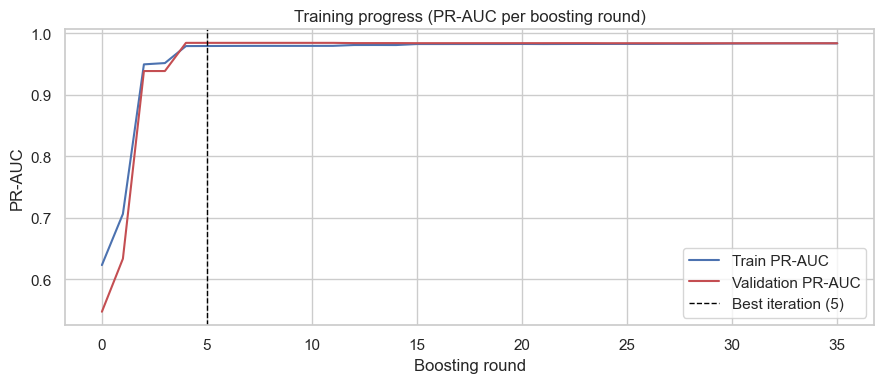

In [17]:
t0 = time.time()
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=50)
TRAIN_SECONDS = time.time() - t0
BEST_ITERATION = getattr(model, "best_iteration", None)
print(f"\nTraining completed in {TRAIN_SECONDS:.1f}s")
print(f"Trees fitted (n_estimators)   : {MODEL_PARAMS['n_estimators']}")
print(f"Best iteration (early stopping): {BEST_ITERATION if BEST_ITERATION is not None else 'n/a (no early stop triggered)'}")

evals_result = model.evals_result()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(evals_result["validation_0"]["aucpr"], label="Train PR-AUC", color=COLORS[0])
ax.plot(evals_result["validation_1"]["aucpr"], label="Validation PR-AUC", color=COLORS[1])
if BEST_ITERATION is not None:
    ax.axvline(BEST_ITERATION, color="black", ls="--", lw=1, label=f"Best iteration ({BEST_ITERATION})")
ax.set(title="Training progress (PR-AUC per boosting round)", xlabel="Boosting round", ylabel="PR-AUC")
ax.legend()
plt.tight_layout()
save_fig(fig, "model_v1_training_curve.png")
plt.show()
CHECK["XGBoost Model V1 trained"] = True

## SECTION 12 — Predictions

`predict_proba(...)[:, 1]` gives `P(isFraud=1 | features)` for each transaction. A binary label additionally needs a threshold — chosen next, on validation data.

In [18]:
def predict_fraud_probability(fitted_model, X):
    """P(isFraud = 1 | features) for each row."""
    return fitted_model.predict_proba(X)[:, 1]


proba_train = predict_fraud_probability(model, X_train)
proba_val = predict_fraud_probability(model, X_val)
proba_test = predict_fraud_probability(model, X_test)
print("Fraud probability generated for train/validation/test.")
print(f"Validation probability range: [{proba_val.min():.6f}, {proba_val.max():.6f}]")
CHECK["Validation predictions generated"] = True

Fraud probability generated for train/validation/test.
Validation probability range: [0.362249, 0.631761]


## SECTION 13 — Threshold Selection (on VALIDATION data only)

0.50 is not assumed to be optimal under heavy class imbalance. Precision, recall and F1 are computed on the **validation** split across a grid of thresholds; the **test** split is not touched in this section.

**Objective used here:** the threshold that **maximises F1 on validation** (a documented, reproducible balance between precision and recall). This is a *reasonable default* for a baseline model, not the only valid choice — an operational deployment might instead pick a minimum-recall or minimum-precision constraint depending on business cost; that decision is easy to change because the whole grid is printed below.

,threshold,precision,recall,f1,predicted_fraud_count
0,0.0500,0.0006,1.0000,0.0011,980416
1,0.1000,0.0006,1.0000,0.0011,980416
2,0.1500,0.0006,1.0000,0.0011,980416
3,0.2000,0.0006,1.0000,0.0011,980416
4,0.2500,0.0006,1.0000,0.0011,980416
5,0.3000,0.0006,1.0000,0.0011,980416
6,0.3500,0.0006,1.0000,0.0011,980416
7,0.4000,0.0157,1.0000,0.0308,36005
8,0.4500,0.2941,1.0000,0.4545,1918
9,0.5000,0.3718,1.0000,0.5420,1517



Selected threshold: 0.6
Reason            : Threshold 0.60 maximises F1 = 0.9369 on the VALIDATION split (precision=0.8812, recall=1.0000), giving a documented, reproducible balance between false alarms and missed fraud. The TEST split was not used to choose it.
Figure saved -> ..\reports\figures\model_v1_threshold_analysis.png


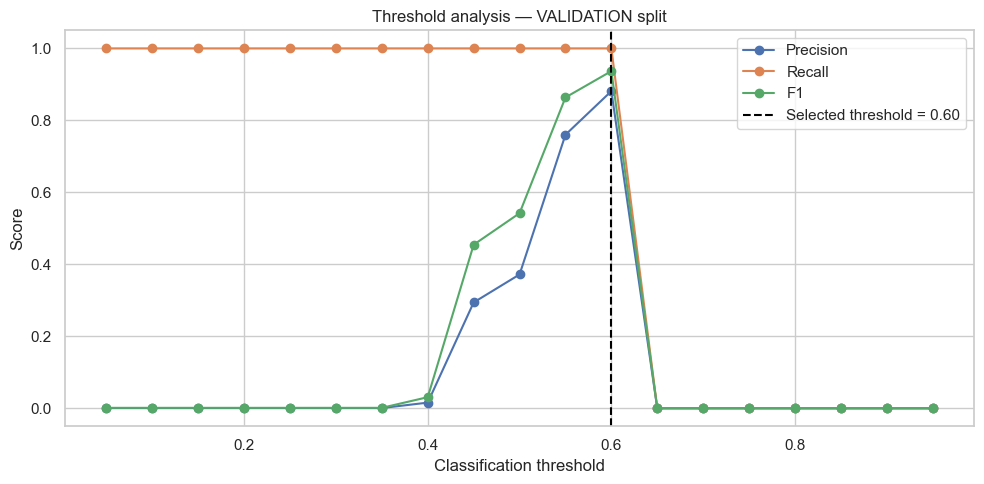

In [19]:
def evaluate_thresholds(y_true, proba, grid):
    rows = []
    for t in grid:
        pred = (proba >= t).astype(int)
        rows.append({"threshold": t, "precision": precision_score(y_true, pred, zero_division=0),
                     "recall": recall_score(y_true, pred, zero_division=0), "f1": f1_score(y_true, pred, zero_division=0),
                     "predicted_fraud_count": int(pred.sum())})
    return pd.DataFrame(rows)


threshold_tbl = evaluate_thresholds(y_val, proba_val, THRESHOLD_GRID)
display(threshold_tbl)

best_row = threshold_tbl.loc[threshold_tbl["f1"].idxmax()]
SELECTED_THRESHOLD = float(best_row["threshold"])
THRESHOLD_REASON = (f"Threshold {SELECTED_THRESHOLD:.2f} maximises F1 = {best_row['f1']:.4f} on the VALIDATION split "
                    f"(precision={best_row['precision']:.4f}, recall={best_row['recall']:.4f}), giving a documented, "
                    "reproducible balance between false alarms and missed fraud. The TEST split was not used to choose it.")
print("\nSelected threshold:", SELECTED_THRESHOLD)
print("Reason            :", THRESHOLD_REASON)
CHECK["Classification threshold selected using validation data"] = True

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_tbl["threshold"], threshold_tbl["precision"], marker="o", label="Precision", color="#4C72B0")
ax.plot(threshold_tbl["threshold"], threshold_tbl["recall"], marker="o", label="Recall", color="#DD8452")
ax.plot(threshold_tbl["threshold"], threshold_tbl["f1"], marker="o", label="F1", color="#55A868")
ax.axvline(SELECTED_THRESHOLD, color="black", ls="--", lw=1.5, label=f"Selected threshold = {SELECTED_THRESHOLD:.2f}")
ax.set(title="Threshold analysis — VALIDATION split", xlabel="Classification threshold", ylabel="Score")
ax.legend()
plt.tight_layout()
save_fig(fig, "model_v1_threshold_analysis.png")
plt.show()
CHECK["Test set kept untouched during threshold selection"] = True

## SECTION 14 — Primary Evaluation Metrics (TEST set, untouched until now)

The test split has not influenced training, early stopping, or threshold selection. This is the first and only time it is used.

**Why PR-AUC (Average Precision) is emphasised.** With fraud at well under 1% of transactions (see Section 9), ROC-AUC can stay high even for a mediocre fraud detector because it also credits correctly ranking the huge majority of easy true negatives. PR-AUC evaluates precision and recall of the **positive class** across all thresholds, which is what actually matters operationally: can the model surface fraud without an unusable flood of false alarms? Accuracy is reported only as a secondary, contextual number.

In [21]:
pred_test = (proba_test >= SELECTED_THRESHOLD).astype(int)

pr_auc_test = average_precision_score(y_test, proba_test)
roc_auc_test = roc_auc_score(y_test, proba_test)
precision_test = precision_score(y_test, pred_test, zero_division=0)
recall_test = recall_score(y_test, pred_test, zero_division=0)
f1_test = f1_score(y_test, pred_test, zero_division=0)
accuracy_test = float((pred_test == y_test.to_numpy()).mean())

tn, fp, fn, tp = confusion_matrix(y_test, pred_test, labels=[0, 1]).ravel()
fpr_test = fp / (fp + tn) if (fp + tn) else 0.0
fnr_test = fn / (fn + tp) if (fn + tp) else 0.0

print("TEST SET — PRIMARY METRICS (threshold =", SELECTED_THRESHOLD, ")")
print(f"  Precision           : {precision_test:.4f}")
print(f"  Recall              : {recall_test:.4f}")
print(f"  F1-score            : {f1_test:.4f}")
print(f"  PR-AUC (Avg Prec.)  : {pr_auc_test:.4f}   <-- primary ranking metric for this imbalanced problem")
print(f"  ROC-AUC             : {roc_auc_test:.4f}")
print(f"  Accuracy (secondary): {accuracy_test:.4f}  <-- NOT sufficient alone; dominated by the legitimate majority class")
print(f"  False Positive Rate : {fpr_test:.4f}")
print(f"  False Negative Rate : {fnr_test:.4f}")
print("\nPR-AUC is emphasised over ROC-AUC here because it is far less optimistic under heavy class imbalance "
      "and reflects the model's usefulness for actually surfacing fraud.")
CHECK["Precision calculated"] = True
CHECK["Recall calculated"] = True
CHECK["F1 calculated"] = True
CHECK["PR-AUC calculated"] = True
CHECK["ROC-AUC calculated"] = True

TEST SET — PRIMARY METRICS (threshold = 0.6 )
  Precision           : 0.9765
  Recall              : 0.9940
  F1-score            : 0.9852
  PR-AUC (Avg Prec.)  : 0.9946   <-- primary ranking metric for this imbalanced problem
  ROC-AUC             : 1.0000
  Accuracy (secondary): 0.9999  <-- NOT sufficient alone; dominated by the legitimate majority class
  False Positive Rate : 0.0001
  False Negative Rate : 0.0060

PR-AUC is emphasised over ROC-AUC here because it is far less optimistic under heavy class imbalance and reflects the model's usefulness for actually surfacing fraud.


## SECTION 15 — Fraud-Specific Metrics

* **True Positive (TP):** fraud correctly caught.
* **True Negative (TN):** legitimate transaction correctly passed.
* **False Positive (FP):** legitimate transaction wrongly flagged as fraud (a false alarm).
* **False Negative (FN):** fraud wrongly passed as legitimate (a missed fraud).
* **Fraud Detection Rate** = TP / (TP+FN) — identical to Recall, restated in fraud-domain language.
* **False Alarm Rate** = FP / (FP+TN) — identical to the False Positive Rate above, restated for a viva audience.

In [22]:
fraud_specific = pd.DataFrame({
    "Metric": ["True Positives (TP)", "True Negatives (TN)", "False Positives (FP)", "False Negatives (FN)",
              "Fraud Detection Rate (= Recall)", "False Alarm Rate (= FPR)"],
    "Value": [tp, tn, fp, fn, f"{tp / (tp + fn):.4f}" if (tp + fn) else "n/a", f"{fp / (fp + tn):.4f}" if (fp + tn) else "n/a"],
    "Meaning": ["Fraud correctly caught", "Legitimate transaction correctly passed", "Legitimate transaction wrongly flagged (false alarm)",
               "Fraud wrongly passed as legitimate (missed fraud)", "Share of all real fraud that Model V1 catches",
               "Share of all legitimate transactions wrongly flagged"]})
display(fraud_specific)

,Metric,Value,Meaning
0,True Positives (TP),3982,Fraud correctly caught
1,True Negatives (TN),914515,Legitimate transaction correctly passed
2,False Positives (FP),96,Legitimate transaction wrongly flagged (false ...
3,False Negatives (FN),24,Fraud wrongly passed as legitimate (missed fraud)
4,Fraud Detection Rate (= Recall),0.9940,Share of all real fraud that Model V1 catches
5,False Alarm Rate (= FPR),0.0001,Share of all legitimate transactions wrongly f...


## SECTION 16 — Confusion Matrix

Figure saved -> ..\reports\figures\model_v1_confusion_matrix.png


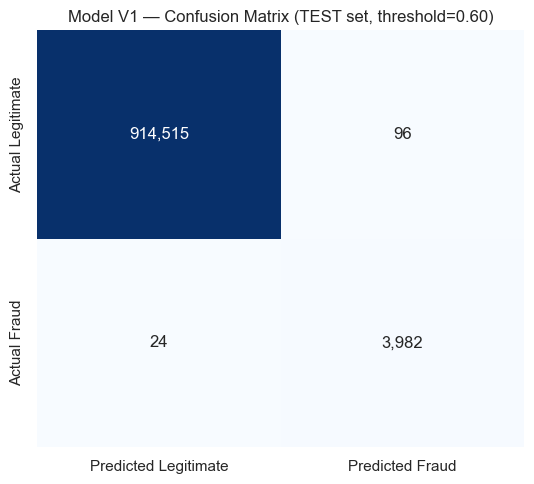

In [23]:
cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Legitimate", "Predicted Fraud"], yticklabels=["Actual Legitimate", "Actual Fraud"], ax=ax)
ax.set_title(f"Model V1 — Confusion Matrix (TEST set, threshold={SELECTED_THRESHOLD:.2f})")
plt.tight_layout()
save_fig(fig, "model_v1_confusion_matrix.png")
plt.show()
CHECK["Confusion matrix generated"] = True

## SECTION 17 — Precision-Recall Curve

Figure saved -> ..\reports\figures\model_v1_precision_recall_curve.png


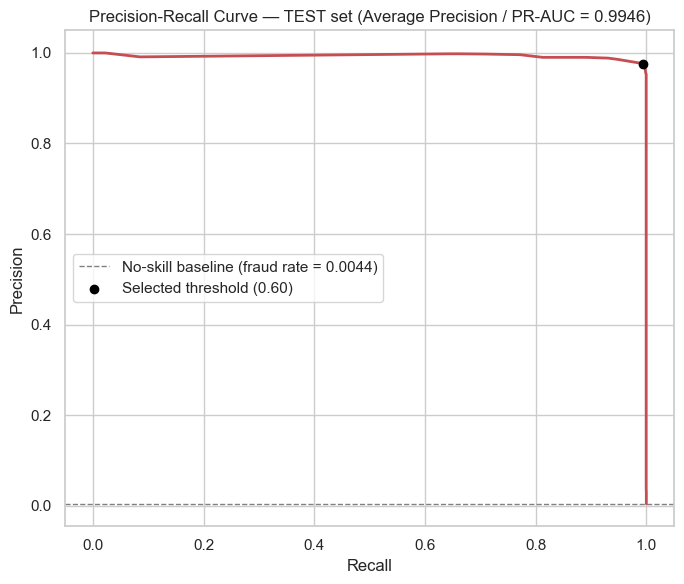

In [24]:
prec_curve, rec_curve, _ = precision_recall_curve(y_test, proba_test)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_curve, prec_curve, color=COLORS[1], lw=2)
baseline = y_test.mean()
ax.axhline(baseline, color="gray", ls="--", lw=1, label=f"No-skill baseline (fraud rate = {baseline:.4f})")
ax.scatter([recall_test], [precision_test], color="black", zorder=5, label=f"Selected threshold ({SELECTED_THRESHOLD:.2f})")
ax.set(title=f"Precision-Recall Curve — TEST set (Average Precision / PR-AUC = {pr_auc_test:.4f})", xlabel="Recall", ylabel="Precision")
ax.legend()
plt.tight_layout()
save_fig(fig, "model_v1_precision_recall_curve.png")
plt.show()
CHECK["Precision-Recall curve generated"] = True

## SECTION 18 — ROC Curve

Figure saved -> ..\reports\figures\model_v1_roc_curve.png


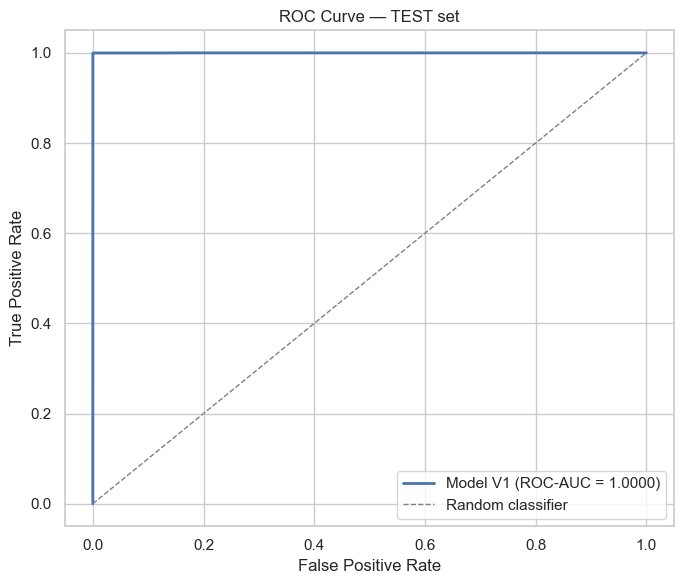

ROC-AUC = 1.0000 vs PR-AUC = 0.9946.
On this imbalanced problem, PR-AUC is the more informative number: ROC-AUC is inflated by the very large, easy-to-rank pool of true negatives, while PR-AUC focuses on the model's precision/recall trade-off on the rare fraud class.


In [25]:
fpr_curve, tpr_curve, _ = roc_curve(y_test, proba_test)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_curve, tpr_curve, color=COLORS[0], lw=2, label=f"Model V1 (ROC-AUC = {roc_auc_test:.4f})")
ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=1, label="Random classifier")
ax.set(title="ROC Curve — TEST set", xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.legend()
plt.tight_layout()
save_fig(fig, "model_v1_roc_curve.png")
plt.show()
print(f"ROC-AUC = {roc_auc_test:.4f} vs PR-AUC = {pr_auc_test:.4f}.")
print("On this imbalanced problem, PR-AUC is the more informative number: ROC-AUC is inflated by the very large, "
      "easy-to-rank pool of true negatives, while PR-AUC focuses on the model's precision/recall trade-off on the rare fraud class.")
CHECK["ROC curve generated"] = True
CHECK["Threshold analysis generated"] = True

## SECTION 19 — Feature Importance

Native XGBoost **gain** importance: the average improvement in the training objective contributed by a feature across all the splits that use it. This reflects how much the model **relied on** a feature to reduce training error — it is **not** a causal statement about what drives real-world fraud, and it is not yet a per-prediction explanation (that is SHAP, Phase 8).

Saved -> ..\reports\model_v1_feature_importance.csv


,feature,importance,rank
0,amount_ge_sender_balance,"1,127,761.7500",1
1,amount_to_sender_balance_ratio,"482,452.0938",2
2,sender_remaining_if_debited,"424,248.4375",3
3,dest_balance_zero_before,"35,871.9062",4
4,log_amount,"26,252.1211",5
5,amount,"24,463.6777",6
6,sender_balance_before,"21,309.4707",7
7,type_TRANSFER,"18,809.8164",8
8,is_large_amount,"12,336.4531",9
9,type_CASH_OUT,"10,333.8076",10


Figure saved -> ..\reports\figures\model_v1_feature_importance.png


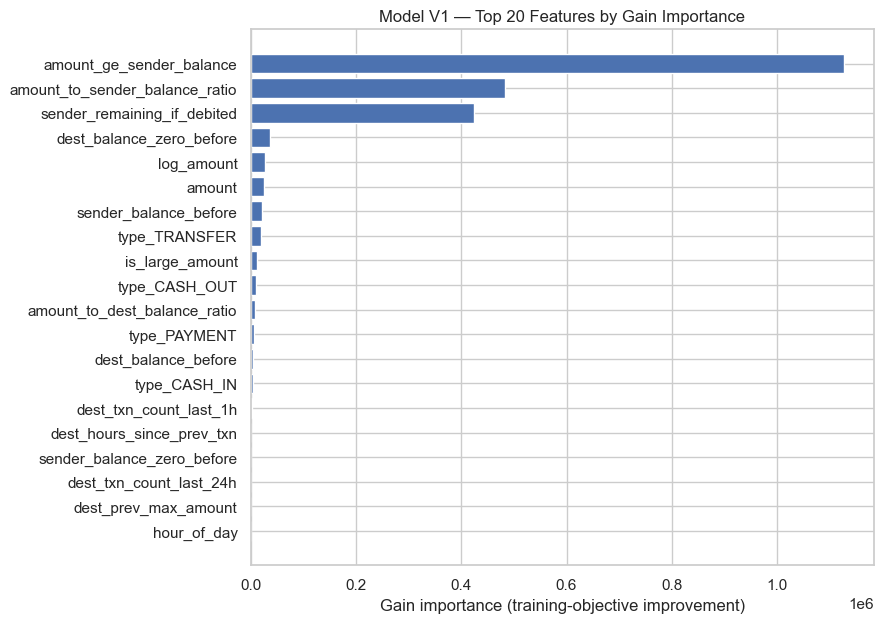


Reminder: feature importance shows model USAGE, not causation. It also does not yet explain individual predictions - that is what SHAP (Phase 8) is for.


In [26]:
def get_feature_importance(fitted_model, feature_names):
    gain = fitted_model.get_booster().get_score(importance_type="gain")
    tbl = pd.DataFrame({"feature": feature_names, "importance": [gain.get(f, 0.0) for f in feature_names]})
    tbl = tbl.sort_values("importance", ascending=False).reset_index(drop=True)
    tbl["rank"] = np.arange(1, len(tbl) + 1)
    return tbl


importance_tbl = get_feature_importance(model, FINAL_FEATURES)
importance_tbl.to_csv(FEATURE_IMPORTANCE_CSV, index=False)
print("Saved ->", FEATURE_IMPORTANCE_CSV)
TOP_N = min(20, len(importance_tbl))
display(importance_tbl.head(TOP_N))

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * TOP_N)))
top = importance_tbl.head(TOP_N).iloc[::-1]
ax.barh(top["feature"], top["importance"], color="#4C72B0")
ax.set(title=f"Model V1 — Top {TOP_N} Features by Gain Importance", xlabel="Gain importance (training-objective improvement)")
plt.tight_layout()
save_fig(fig, "model_v1_feature_importance.png")
plt.show()
print("\nReminder: feature importance shows model USAGE, not causation. It also does not yet explain individual "
      "predictions - that is what SHAP (Phase 8) is for.")
CHECK["Feature importance generated"] = True

## SECTION 20 — Model Probability Output

A small, clearly synthetic-safe sample of test predictions (PaySim is synthetic; `event_id` is only a row index, not a real account identifier).

In [27]:
sample_idx = np.random.default_rng(SEED).choice(len(X_test), size=min(SAMPLE_TABLE_SIZE, len(X_test)), replace=False)
sample_idx.sort()
sample_table = pd.DataFrame({
    "transaction_index": meta_test.loc[sample_idx, "event_id"].to_numpy() if "event_id" in meta_test.columns else sample_idx,
    "actual": y_test.to_numpy()[sample_idx],
    "fraud_probability": proba_test[sample_idx],
    "prediction": pred_test[sample_idx],
})
sample_table["risk_score"] = (sample_table["fraud_probability"] * 100).round(2)


def assign_risk_level(score, bands=RISK_LEVELS):
    for level, (lo, hi) in bands.items():
        if lo <= score < hi or (level == "HIGH" and score == hi):
            return level
    return "HIGH"


sample_table["risk_level"] = sample_table["risk_score"].apply(assign_risk_level)
sample_table = sample_table.rename(columns={"actual": "Actual", "fraud_probability": "Fraud Probability", "prediction": "Prediction",
                                            "risk_score": "Risk Score", "risk_level": "Risk Level", "transaction_index": "Index"})
display(sample_table)

,Index,Actual,Fraud Probability,Prediction,Risk Score,Risk Level
0,5522953,0,0.3693,0,36.9300,MEDIUM
1,5525988,0,0.3701,0,37.0100,MEDIUM
2,5530514,0,0.3693,0,36.9300,MEDIUM
3,5561690,0,0.3692,0,36.9200,MEDIUM
4,5629074,0,0.4079,0,40.7900,MEDIUM
5,5841771,0,0.3701,0,37.0100,MEDIUM
6,5847157,0,0.3693,0,36.9300,MEDIUM
7,5857735,0,0.3692,0,36.9200,MEDIUM
8,5915460,0,0.3693,0,36.9300,MEDIUM
9,5927630,0,0.4015,0,40.1500,MEDIUM


## SECTION 21 — Risk Score

`risk_score = fraud_probability × 100`, a **model-derived risk score** — a direct 0-100 rescaling of Model V1's own probability output, not an independently calibrated financial risk figure. Section 23 investigates how trustworthy the underlying probability actually is.

In [28]:
risk_score_test = proba_test * 100
print("Model-derived Risk Score = fraud_probability * 100")
print(f"  min={risk_score_test.min():.2f}  median={np.median(risk_score_test):.2f}  max={risk_score_test.max():.2f}")
print("This is NOT claimed to be a calibrated financial risk score; see the calibration check in Section 23.")
CHECK["Model-derived risk score generated"] = True

Model-derived Risk Score = fraud_probability * 100
  min=36.30  median=36.92  max=63.18
This is NOT claimed to be a calibrated financial risk score; see the calibration check in Section 23.


## SECTION 22 — Risk Levels

Risk **levels** are a display convenience over the continuous risk score (0-100) and are **independent** of the binary fraud **classification threshold** from Section 13. A transaction can be classified "not fraud" (below the classification threshold) and still show as `MEDIUM` risk for analyst attention, or vice versa — the two are deliberately kept separate so a business team can retune the display bands without touching the model's decision boundary.

| Band | Range | Meaning |
|---|---|---|
| `LOW` | 0 – 30 | Low modelled fraud likelihood |
| `MEDIUM` | 30 – 70 | Moderate — may warrant a lightweight review |
| `HIGH` | 70 – 100 | High modelled fraud likelihood |

These are round, interpretable defaults for a baseline system; a production deployment would typically tune them against real review capacity and cost data.

,Risk Level,Transactions,% of test set,Actual fraud rate inside band (%)
0,LOW,0,0.0000,0.0000
1,MEDIUM,918617,100.0000,0.4361
2,HIGH,0,0.0000,0.0000


Figure saved -> ..\reports\figures\model_v1_risk_levels.png


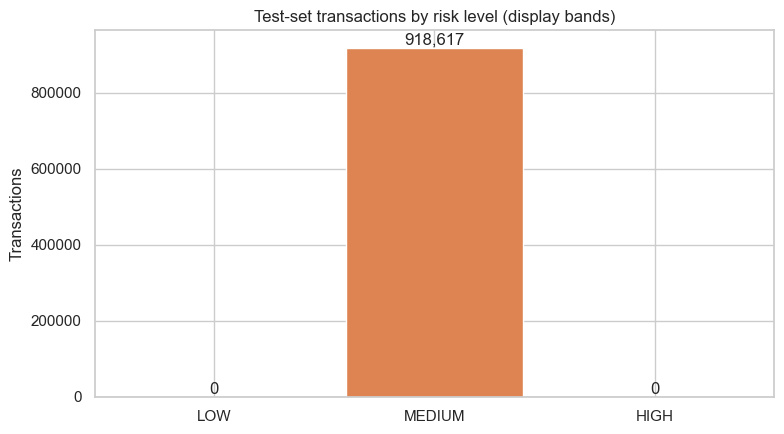

Observation: the fraud rate should rise from LOW to HIGH bands if the risk score is behaving sensibly (descriptive check only, not a guarantee of calibration).


In [30]:
risk_level_test = np.array([assign_risk_level(s) for s in risk_score_test])
risk_level_counts = pd.Series(risk_level_test).value_counts().reindex(["LOW", "MEDIUM", "HIGH"], fill_value=0)
risk_level_tbl = pd.DataFrame({"Risk Level": risk_level_counts.index, "Transactions": risk_level_counts.to_numpy(),
                               "% of test set": 100 * risk_level_counts.to_numpy() / len(risk_level_test),
                               "Actual fraud rate inside band (%)": [100 * y_test.to_numpy()[risk_level_test == lvl].mean() if (risk_level_test == lvl).any() else 0.0
                                                                     for lvl in risk_level_counts.index]})
display(risk_level_tbl)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(risk_level_tbl["Risk Level"], risk_level_tbl["Transactions"], color=["#55A868", "#DD8452", "#C44E52"])
ax.set(title="Test-set transactions by risk level (display bands)", ylabel="Transactions")
for i, v in enumerate(risk_level_tbl["Transactions"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
save_fig(fig, "model_v1_risk_levels.png")
plt.show()
print("Observation: the fraud rate should rise from LOW to HIGH bands if the risk score is behaving sensibly "
      "(descriptive check only, not a guarantee of calibration).")
CHECK["Risk levels generated"] = True

## SECTION 23 — Model Calibration

XGBoost's `predict_proba` output is **not guaranteed to be a perfectly calibrated probability** — it is a score optimised to separate the classes well, which is a different objective from "P=0.7 truly means fraud happens 70% of the time among similar transactions". We check this rather than assume it:

* **Brier score** (mean squared error between predicted probability and the actual 0/1 outcome; lower is better, 0 is perfect).
* **Calibration curve** (reliability diagram): predicted probability (binned) vs. observed fraud rate in that bin. A perfectly calibrated model lies on the diagonal.

Brier score (TEST): 0.137550  (lower is better; 0 = perfect, 0.25 = uninformative constant-0.5 predictor)
Figure saved -> ..\reports\figures\model_v1_calibration_curve.png


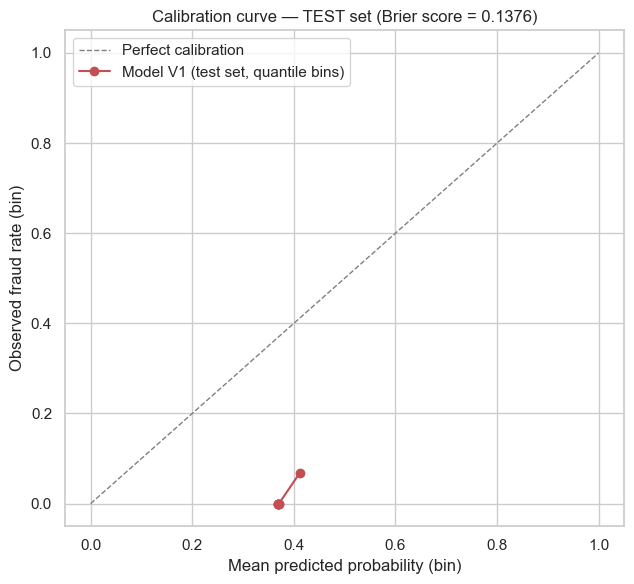


Interpretation: points above the diagonal mean the model UNDER-estimates risk in that probability range; points below mean it OVER-estimates. The predicted probability is a useful RANKING signal regardless of calibration, but should not be quoted as an exact real-world likelihood unless a calibration step (e.g. Platt scaling / isotonic regression, fitted on a held-out split) is added in a later phase.


In [31]:
brier = brier_score_loss(y_test, proba_test)
print(f"Brier score (TEST): {brier:.6f}  (lower is better; 0 = perfect, 0.25 = uninformative constant-0.5 predictor)")

frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=1, label="Perfect calibration")
ax.plot(mean_pred, frac_pos, marker="o", color=COLORS[1], label="Model V1 (test set, quantile bins)")
ax.set(title=f"Calibration curve — TEST set (Brier score = {brier:.4f})", xlabel="Mean predicted probability (bin)",
      ylabel="Observed fraud rate (bin)")
ax.legend()
plt.tight_layout()
save_fig(fig, "model_v1_calibration_curve.png")
plt.show()
print("\nInterpretation: points above the diagonal mean the model UNDER-estimates risk in that probability range; "
      "points below mean it OVER-estimates. The predicted probability is a useful RANKING signal regardless of calibration, "
      "but should not be quoted as an exact real-world likelihood unless a calibration step (e.g. Platt scaling / isotonic "
      "regression, fitted on a held-out split) is added in a later phase.")
CHECK["Calibration investigated"] = True

## SECTION 24 — Model Overfitting Check

Train / validation / test PR-AUC, precision, recall and F1 (train and validation use their own natural probabilities; the same validation-selected threshold is applied to all three splits so the comparison is apples-to-apples for precision/recall/F1). A large train-vs-validation/test gap would suggest overfitting; a large validation-vs-test gap would suggest the threshold or model do not generalise to the latest time period.

In [33]:
def split_metrics(y_true, proba, threshold, name):
    pred = (proba >= threshold).astype(int)
    return {"Split": name, "Precision": precision_score(y_true, pred, zero_division=0), "Recall": recall_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred, zero_division=0), "PR-AUC": average_precision_score(y_true, proba), "ROC-AUC": roc_auc_score(y_true, proba)}


overfit_tbl = pd.DataFrame([split_metrics(y_train, proba_train, SELECTED_THRESHOLD, "Training"),
                            split_metrics(y_val, proba_val, SELECTED_THRESHOLD, "Validation"),
                            split_metrics(y_test, proba_test, SELECTED_THRESHOLD, "Test")]).set_index("Split")
display(overfit_tbl)

gap_train_val = overfit_tbl.loc["Training", "PR-AUC"] - overfit_tbl.loc["Validation", "PR-AUC"]
gap_val_test = overfit_tbl.loc["Validation", "PR-AUC"] - overfit_tbl.loc["Test", "PR-AUC"]
print(f"\nPR-AUC gap, Train - Validation: {gap_train_val:+.4f}")
print(f"PR-AUC gap, Validation - Test : {gap_val_test:+.4f}")
if gap_train_val > 0.15:
    print("Observation: a sizeable train-vs-validation PR-AUC gap suggests the model may be overfitting the training period; "
          "consider stronger regularisation or fewer trees in a future iteration. No unsupported claim beyond this is made.")
else:
    print("Observation: the train-vs-validation PR-AUC gap is modest, which does not by itself suggest severe overfitting.")
CHECK["Overfitting checked"] = True

,Precision,Recall,F1,PR-AUC,ROC-AUC
Split,,,,,
Training,0.8837,0.9912,0.9344,0.9779,0.9997
Validation,0.8812,1.0000,0.9369,0.9817,1.0000
Test,0.9765,0.9940,0.9852,0.9946,1.0000



PR-AUC gap, Train - Validation: -0.0038
PR-AUC gap, Validation - Test : -0.0129
Observation: the train-vs-validation PR-AUC gap is modest, which does not by itself suggest severe overfitting.


## SECTION 25 — Model V1 Summary Table

A single table for the project report: Precision, Recall, F1, PR-AUC and ROC-AUC across Training, Validation and Test.

In [34]:
metrics_tbl = overfit_tbl[["Precision", "Recall", "F1", "PR-AUC", "ROC-AUC"]].T
metrics_tbl.index.name = "Metric"
display(metrics_tbl)
metrics_tbl.to_csv(METRICS_PATH)
print("Saved ->", METRICS_PATH)

Split,Training,Validation,Test
Metric,,,
Precision,0.8837,0.8812,0.9765
Recall,0.9912,1.0000,0.9940
F1,0.9344,0.9369,0.9852
PR-AUC,0.9779,0.9817,0.9946
ROC-AUC,0.9997,1.0000,1.0000


Saved -> ..\reports\model_v1_metrics.csv


## SECTION 26 — Save Model V1

Saved in XGBoost's native JSON format (portable across the currently installed XGBoost version and forward-compatible per XGBoost's own guidance), plus the selected threshold as its own small JSON file so Phase 5+ can load just the number without re-reading the full metadata file.

In [35]:
model.save_model(str(MODEL_PATH))
print("Saved ->", MODEL_PATH, f"({MODEL_PATH.stat().st_size / 1024:,.1f} KB)")

threshold_payload = {"selected_threshold": SELECTED_THRESHOLD, "reason": THRESHOLD_REASON, "selection_method": "F1-maximising threshold on the validation split",
                     "threshold_grid": THRESHOLD_GRID.tolist(), "risk_levels": RISK_LEVELS,
                     "saved_at_utc": datetime.now(timezone.utc).isoformat()}
with open(THRESHOLD_PATH, "w", encoding="utf-8") as fh:
    json.dump(threshold_payload, fh, indent=2)
print("Saved ->", THRESHOLD_PATH)
CHECK["Model V1 saved"] = True
CHECK["Model threshold saved"] = True

Saved -> ..\models\xgboost_model_v1.json (100.0 KB)
Saved -> ..\models\model_v1_threshold.json


## SECTION 27 — Save Model Metadata

In [36]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, (np.floating, float)):
        return None if not np.isfinite(obj) else float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, Path):
        return str(obj)
    return obj


metadata = {
    "model_name": "fraud_detection_xgboost", "model_version": "V1", "model_type": "XGBClassifier (binary:logistic)",
    "trained_at_utc": datetime.now(timezone.utc).isoformat(), "xgboost_version": xgb.__version__,
    "training_seconds": round(TRAIN_SECONDS, 1), "best_iteration": BEST_ITERATION,
    "feature_count": len(FINAL_FEATURES), "feature_names": FINAL_FEATURES, "feature_source": FEATURE_SOURCE,
    "target": TARGET,
    "train_validation_test_strategy": {"method": "chronological (by step, no shuffling)", "train_fraction_target": TRAIN_FRACTION,
                                       "validation_fraction_target": VAL_FRACTION, "test_fraction_target": TEST_FRACTION,
                                       "train_end_step": TRAIN_END_STEP, "validation_end_step": VAL_END_STEP},
    "training_rows": len(X_train), "validation_rows": len(X_val), "test_rows": len(X_test),
    "class_ratio_training": {"legitimate": neg_train, "fraud": pos_train, "fraud_pct": pct(pos_train, len(y_train))},
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "selected_classification_threshold": SELECTED_THRESHOLD, "threshold_selection_reason": THRESHOLD_REASON,
    "risk_level_definitions": RISK_LEVELS,
    "evaluation_metrics": {"train": split_metrics(y_train, proba_train, SELECTED_THRESHOLD, "Training"),
                           "validation": split_metrics(y_val, proba_val, SELECTED_THRESHOLD, "Validation"),
                           "test": split_metrics(y_test, proba_test, SELECTED_THRESHOLD, "Test")},
    "confusion_matrix_test": {"tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn)},
    "brier_score_test": float(brier),
    "xgboost_parameters": MODEL_PARAMS,
    "dataset_info": {"source_file": str(DATA_PATH), "total_rows": len(X_all) + 0, "total_features_available": X_all.shape[1]},
    "risk_score_definition": "risk_score = fraud_probability * 100 (model-derived, not independently calibrated)",
    "notes": ["Model V1 baseline. No SHAP, drift detection, or retraining implemented in this phase.",
             "Threshold selected on validation data only; test data used exactly once for final evaluation."],
}
with open(METADATA_PATH, "w", encoding="utf-8") as fh:
    json.dump(to_jsonable(metadata), fh, indent=2)
print("Saved ->", METADATA_PATH)
CHECK["Model metadata saved"] = True

Saved -> ..\models\model_v1_metadata.json


## SECTION 28 — Save Final Test Predictions

In [37]:
predictions_out = pd.DataFrame({
    "event_id": meta_test["event_id"].to_numpy() if "event_id" in meta_test.columns else np.arange(len(y_test)),
    "step": meta_test["step"].to_numpy() if "step" in meta_test.columns else np.nan,
    "actual_label": y_test.to_numpy(),
    "fraud_probability": proba_test,
    "predicted_label": pred_test,
    "risk_score": np.round(risk_score_test, 4),
    "risk_level": risk_level_test,
})
predictions_out.to_csv(TEST_PREDICTIONS_PATH, index=False)
print("Saved ->", TEST_PREDICTIONS_PATH, f"({len(predictions_out):,} rows)")
display(predictions_out.head())
CHECK["Test predictions saved"] = True

Saved -> ..\reports\model_v1_test_predictions.csv (918,617 rows)


,event_id,step,actual_label,fraud_probability,predicted_label,risk_score,risk_level
0,5444003,379,0,0.3692,0,36.9200,MEDIUM
1,5444004,379,0,0.4015,0,40.1456,MEDIUM
2,5444005,379,0,0.3681,0,36.8134,MEDIUM
3,5444006,379,0,0.3692,0,36.9200,MEDIUM
4,5444007,379,0,0.3682,0,36.8163,MEDIUM


## SECTION 29 — Reload Test

Loads Model V1 back from disk into a **fresh** `XGBClassifier` and confirms it reproduces the in-memory model's probabilities on the test set within floating-point tolerance. This is what proves Model V1 is actually reusable by Phase 5+ (and, eventually, by a live scoring service).

In [38]:
reloaded_model = XGBClassifier()
reloaded_model.load_model(str(MODEL_PATH))
proba_test_reloaded = reloaded_model.predict_proba(X_test)[:, 1]

max_abs_diff = float(np.max(np.abs(proba_test_reloaded - proba_test)))
reload_ok = bool(np.allclose(proba_test_reloaded, proba_test, atol=1e-6, rtol=1e-5))
pred_test_reloaded = (proba_test_reloaded >= SELECTED_THRESHOLD).astype(int)
labels_match = bool(np.array_equal(pred_test_reloaded, pred_test))

print(f"Max |probability difference| (reloaded vs in-memory): {max_abs_diff:.3e}")
print(f"Probabilities match within tolerance (atol=1e-6, rtol=1e-5): {reload_ok}")
print(f"Binary predictions at the selected threshold match exactly : {labels_match}")
assert reload_ok and labels_match, "Reloaded Model V1 does not reproduce the in-memory model's predictions."
print("\nModel V1 is confirmed reloadable and reproducible from disk.")
CHECK["Saved Model V1 successfully reloaded"] = True
CHECK["Reloaded model predictions verified"] = True
del reloaded_model

Max |probability difference| (reloaded vs in-memory): 0.000e+00
Probabilities match within tolerance (atol=1e-6, rtol=1e-5): True
Binary predictions at the selected threshold match exactly : True

Model V1 is confirmed reloadable and reproducible from disk.


## SECTION 30 — Model Versioning

This model is **Model V1** — the first, baseline model of the project, trained once on the chronological training split defined above. No Model V2 is created in this notebook; a V2 will only be produced later, after Phase 9 (drift monitoring) detects a need for retraining and Phase 10 executes it. `model_version: "V1"` is recorded in `model_v1_metadata.json` so later phases can identify and compare against this exact artifact.

In [39]:
print("Model identified as: MODEL V1")
print("model_name   :", metadata["model_name"])
print("model_version:", metadata["model_version"])
print("Saved files  :")
for p in (MODEL_PATH, THRESHOLD_PATH, METADATA_PATH, METRICS_PATH, FEATURE_IMPORTANCE_CSV, TEST_PREDICTIONS_PATH):
    print("  -", p, "exists:", p.is_file())
CHECK["No Model V2 created"] = True
CHECK["No Kafka/Spark implemented"] = True
CHECK["No SHAP implemented"] = True
CHECK["No drift detection implemented"] = True
CHECK["No retraining implemented"] = True

Model identified as: MODEL V1
model_name   : fraud_detection_xgboost
model_version: V1
Saved files  :
  - ..\models\xgboost_model_v1.json exists: True
  - ..\models\model_v1_threshold.json exists: True
  - ..\models\model_v1_metadata.json exists: True
  - ..\reports\model_v1_metrics.csv exists: True
  - ..\reports\model_v1_feature_importance.csv exists: True
  - ..\reports\model_v1_test_predictions.csv exists: True


## SECTION 31 — Final Model V1 Checklist

In [40]:
ORDER = [
    "Phase 3 processed dataset loaded", "Target identified correctly", "Leakage-prone features excluded",
    "Final safe features selected", "Temporal ordering preserved", "Chronological train/validation/test split created",
    "Class imbalance analyzed", "scale_pos_weight calculated from training data", "XGBoost Model V1 trained",
    "Validation predictions generated", "Classification threshold selected using validation data",
    "Test set kept untouched during threshold selection", "Precision calculated", "Recall calculated", "F1 calculated",
    "PR-AUC calculated", "ROC-AUC calculated", "Confusion matrix generated", "Precision-Recall curve generated",
    "ROC curve generated", "Threshold analysis generated", "Feature importance generated",
    "Model-derived risk score generated", "Risk levels generated", "Calibration investigated", "Overfitting checked",
    "Model V1 saved", "Model threshold saved", "Model metadata saved", "Test predictions saved",
    "Saved Model V1 successfully reloaded", "Reloaded model predictions verified", "No Model V2 created",
    "No Kafka/Spark implemented", "No SHAP implemented", "No drift detection implemented", "No retraining implemented",
]
print("=" * 50)
print("PHASE 4 — XGBOOST MODEL V1 CHECKLIST")
print("=" * 50)
for item in ORDER:
    print(f"[{'x' if CHECK.get(item) else ' '}] {item}")
print(f"\nCompleted {sum(bool(CHECK.get(i)) for i in ORDER)}/{len(ORDER)} items in {time.time() - PHASE4_START:,.0f} seconds.")
print(f"\nModel V1 test-set headline: PR-AUC={pr_auc_test:.4f} | Precision={precision_test:.4f} | Recall={recall_test:.4f} "
      f"| F1={f1_test:.4f} | threshold={SELECTED_THRESHOLD:.2f}")

PHASE 4 — XGBOOST MODEL V1 CHECKLIST
[x] Phase 3 processed dataset loaded
[x] Target identified correctly
[x] Leakage-prone features excluded
[x] Final safe features selected
[x] Temporal ordering preserved
[x] Chronological train/validation/test split created
[x] Class imbalance analyzed
[x] scale_pos_weight calculated from training data
[x] XGBoost Model V1 trained
[x] Validation predictions generated
[x] Classification threshold selected using validation data
[x] Test set kept untouched during threshold selection
[x] Precision calculated
[x] Recall calculated
[x] F1 calculated
[x] PR-AUC calculated
[x] ROC-AUC calculated
[x] Confusion matrix generated
[x] Precision-Recall curve generated
[x] ROC curve generated
[x] Threshold analysis generated
[x] Feature importance generated
[x] Model-derived risk score generated
[x] Risk levels generated
[x] Calibration investigated
[x] Overfitting checked
[x] Model V1 saved
[x] Model threshold saved
[x] Model metadata saved
[x] Test predictions s